# Exploración de Datos: ICFES, Internet y Cobertura Educativa
Este notebook presenta el análisis exploratorio de los tres datasets descargados desde datos.gov.co:
- **ICFES Saber 11**: Resultados individuales por estudiante
- **Internet por municipio**: Accesos a internet fijo
- **Cobertura educativa**: Indicadores por municipio y año

## 0. Imports y configuración

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = sns.color_palette('muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

PARQUET_DIR = Path('data/parquet')
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga de datos desde Parquet

In [2]:
df_icfes    = pd.read_parquet(PARQUET_DIR / 'icfes')
df_internet = pd.read_parquet(PARQUET_DIR / 'internet')
df_bach     = pd.read_parquet(PARQUET_DIR / 'bachillerato')

# ── Conversiones numéricas ─────────────────────────────────────────────────────
for col in ['punt_ingles', 'punt_matematicas']:
    df_icfes[col] = pd.to_numeric(df_icfes[col], errors='coerce')

for col in ['no_de_accesos', 'velocidad_bajada', 'velocidad_subida']:
    df_internet[col] = pd.to_numeric(df_internet[col], errors='coerce')

num_bach_cols = [
    'cobertura_neta', 'cobertura_neta_primaria', 'cobertura_neta_secundaria',
    'cobertura_neta_media', 'cobertura_bruta', 'deserci_n', 'deserci_n_primaria',
    'deserci_n_secundaria', 'aprobaci_n', 'reprobaci_n', 'repitencia',
    'sedes_conectadas_a_internet', 'tasa_matriculaci_n_5_16',
    'poblaci_n_5_16', 'tama_o_promedio_de_grupo'
]
for col in num_bach_cols:
    df_bach[col] = pd.to_numeric(df_bach[col], errors='coerce')

print(f'ICFES       : {df_icfes.shape[0]:,} filas × {df_icfes.shape[1]} columnas')
print(f'Internet    : {df_internet.shape[0]:,} filas × {df_internet.shape[1]} columnas')
print(f'Bachillerato: {df_bach.shape[0]:,} filas × {df_bach.shape[1]} columnas')

ICFES       : 7,109,704 filas × 51 columnas
Internet    : 2,795,052 filas × 12 columnas
Bachillerato: 15,707 filas × 41 columnas


---
## Elemento 1 — Estadísticos descriptivos generales (tres datasets)

In [3]:
print('=== ICFES – Puntajes numéricos ===')
display(df_icfes[['punt_ingles', 'punt_matematicas']].describe().round(2))

print('\n=== Internet – Variables numéricas ===')
display(df_internet[['no_de_accesos', 'velocidad_bajada', 'velocidad_subida']].describe().round(2))

print('\n=== Cobertura educativa – Tasas e indicadores ===')
display(df_bach[num_bach_cols].describe().round(2))

=== ICFES – Puntajes numéricos ===


,punt_ingles,punt_matematicas
count,7105518.00,7109697.00
mean,48.59,49.30
std,12.23,11.91
min,-1.00,0.00
25%,41.00,41.00
50%,46.00,49.00
75%,54.00,57.00
max,117.29,127.00



=== Internet – Variables numéricas ===


,no_de_accesos,velocidad_bajada,velocidad_subida
count,2795052.00,0.0,0.0
mean,71.95,NaN,NaN
std,949.81,NaN,NaN
min,0.00,NaN,NaN
25%,1.00,NaN,NaN
50%,3.00,NaN,NaN
75%,15.00,NaN,NaN
max,235431.00,NaN,NaN



=== Cobertura educativa – Tasas e indicadores ===


,cobertura_neta,cobertura_neta_primaria,cobertura_neta_secundaria,cobertura_neta_media,cobertura_bruta,deserci_n,deserci_n_primaria,deserci_n_secundaria,aprobaci_n,reprobaci_n,repitencia,sedes_conectadas_a_internet,tasa_matriculaci_n_5_16,poblaci_n_5_16,tama_o_promedio_de_grupo
count,15596.00,15616.00,15613.00,15614.00,15639.00,15565.00,15465.00,15437.00,15682.00,15621.00,15564.00,7768.00,15592.00,15700.00,7572.00
mean,85.23,82.26,69.84,41.00,99.01,3.49,2.75,4.58,91.55,4.83,3.68,34.83,84.69,10060.86,23.95
std,16.88,17.11,18.70,15.61,143.35,2.15,2.02,3.07,5.28,3.94,3.61,26.18,18.42,138798.67,7.70
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,3.00
25%,76.42,72.90,60.37,31.40,85.08,1.95,1.27,2.38,88.44,1.18,0.80,14.29,74.59,1174.00,19.43
50%,86.04,82.50,70.80,41.40,96.97,3.15,2.32,4.06,91.92,4.67,2.46,28.13,85.02,2655.00,23.96
75%,94.27,91.60,80.40,50.70,108.61,4.64,3.75,6.20,95.43,7.43,5.79,50.00,95.00,5889.25,27.84
max,264.54,254.96,229.44,170.26,10448.00,27.90,18.31,47.14,100.00,49.39,37.47,100.00,279.03,9548263.00,54.03


---
## Elemento 2 — Valores nulos por dataset (tabla resumen)

In [4]:
def null_summary(df, name):
    total = len(df)
    s = df.isnull().sum()
    pct = (s / total * 100).round(2)
    out = pd.DataFrame({'nulos': s, '% nulos': pct})
    out = out[out['nulos'] > 0].sort_values('% nulos', ascending=False)
    out.index.name = 'columna'
    print(f'\n── {name} ({total:,} registros) ──')
    display(out)

null_summary(df_icfes, 'ICFES')
null_summary(df_internet, 'Internet')
null_summary(df_bach, 'Cobertura educativa')


── ICFES (7,109,704 registros) ──


,nulos,% nulos
columna,,
punt_lectura_critica,2609523,36.70
punt_sociales_ciudadanas,2609523,36.70
punt_c_naturales,2609523,36.70
punt_global,2609523,36.70
cole_bilingue,916870,12.90
fami_estratovivienda,218219,3.07
fami_educacionpadre,212423,2.99
fami_educacionmadre,212826,2.99
fami_tieneinternet,191624,2.70



── Internet (2,795,052 registros) ──


,nulos,% nulos
columna,,
velocidad_subida,2795052,100.0
velocidad_bajada,2795052,100.0
cod_municipio,10,0.0
cod_departamento,5,0.0



── Cobertura educativa (15,707 registros) ──


,nulos,% nulos
columna,,
tama_o_promedio_de_grupo,8135,51.79
sedes_conectadas_a_internet,7939,50.54
deserci_n_transici_n,903,5.75
deserci_n_media,734,4.67
deserci_n_secundaria,270,1.72
deserci_n_primaria,242,1.54
repitencia_transici_n,159,1.01
repitencia_secundaria,152,0.97
repitencia_primaria,148,0.94


---
## Elemento 3 — Distribución de puntajes ICFES (Inglés y Matemáticas)

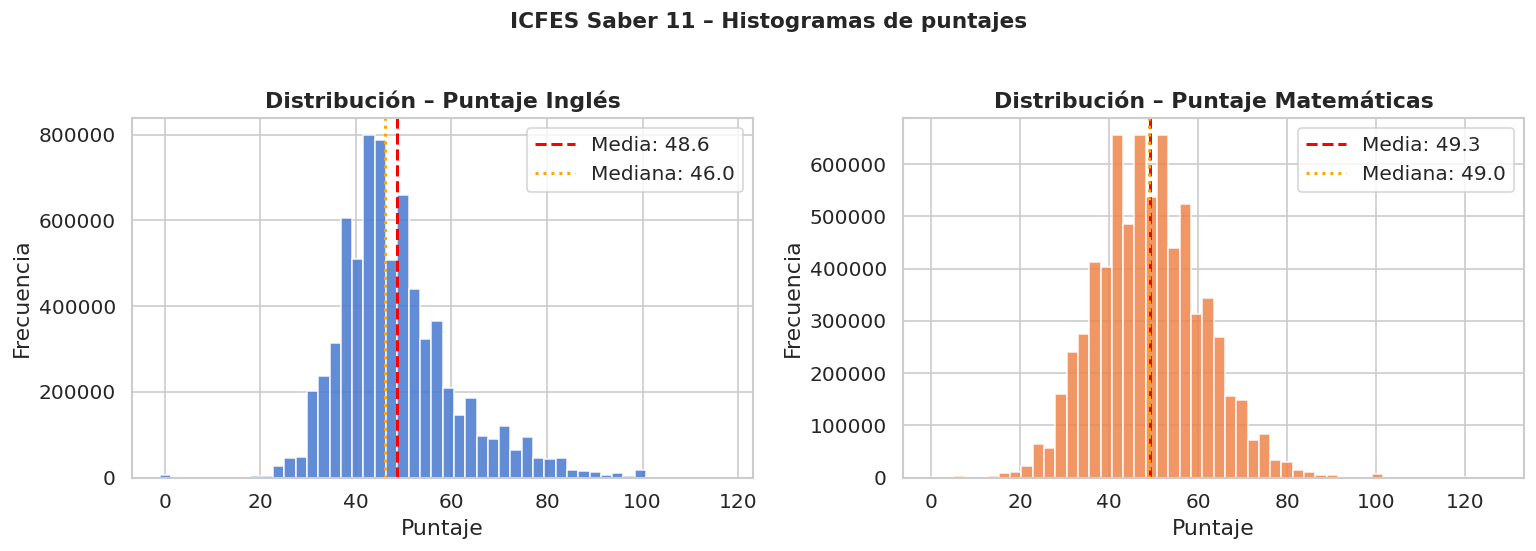

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, col, color, label in zip(
    axes,
    ['punt_ingles', 'punt_matematicas'],
    [PALETTE[0], PALETTE[1]],
    ['Inglés', 'Matemáticas']
):
    datos = df_icfes[col].dropna()
    ax.hist(datos, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(datos.mean(),   color='red',    lw=1.8, ls='--', label=f'Media: {datos.mean():.1f}')
    ax.axvline(datos.median(), color='orange', lw=1.8, ls=':',  label=f'Mediana: {datos.median():.1f}')
    ax.set_title(f'Distribución – Puntaje {label}', fontweight='bold')
    ax.set_xlabel('Puntaje')
    ax.set_ylabel('Frecuencia')
    ax.legend()

fig.suptitle('ICFES Saber 11 – Histogramas de puntajes', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Elemento 4 — Puntaje promedio ICFES por género y estrato socioeconómico

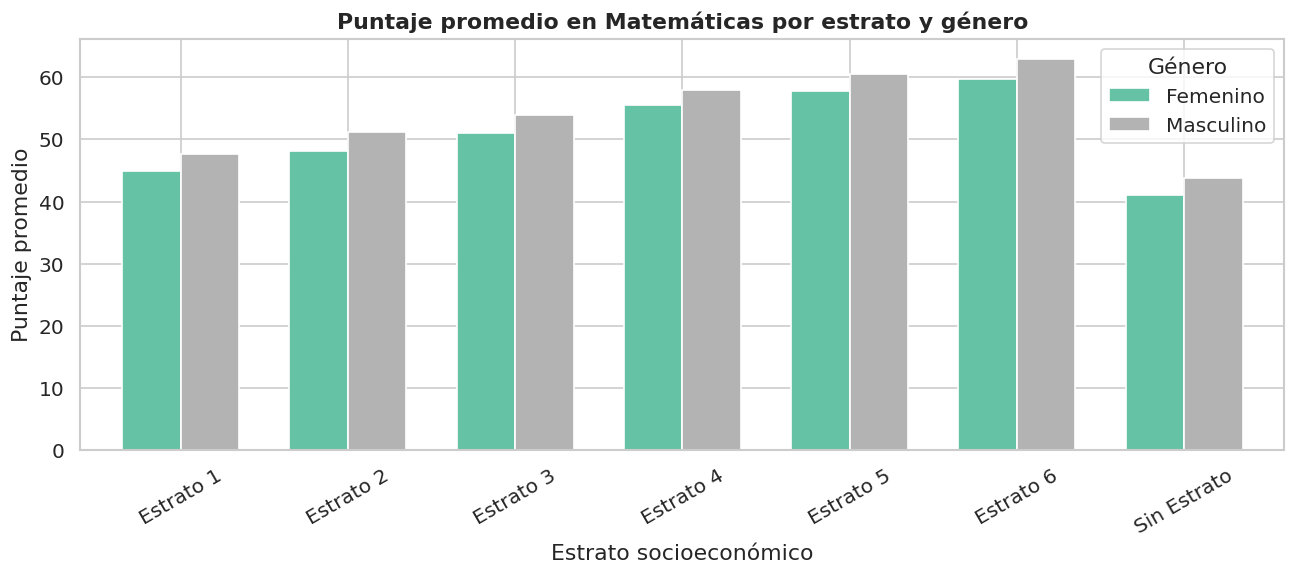


Tabla: puntaje promedio Matemáticas por estrato y género


estu_genero,F,M
fami_estratovivienda,,
Estrato 1,44.9,47.6
Estrato 2,48.1,51.2
Estrato 3,51.1,54.0
Estrato 4,55.5,58.0
Estrato 5,57.7,60.5
Estrato 6,59.7,63.0
Sin Estrato,41.1,43.8


In [6]:
orden_estrato = [
    'Estrato 1', 'Estrato 2', 'Estrato 3',
    'Estrato 4', 'Estrato 5', 'Estrato 6', 'Sin Estrato'
]

icfes_f = df_icfes[
    df_icfes['estu_genero'].isin(['M', 'F']) &
    df_icfes['fami_estratovivienda'].notna()
].copy()

pivot = (
    icfes_f
    .groupby(['fami_estratovivienda', 'estu_genero'])['punt_matematicas']
    .mean()
    .unstack('estu_genero')
    .reindex([e for e in orden_estrato if e in icfes_f['fami_estratovivienda'].unique()])
)

ax = pivot.plot(kind='bar', figsize=(11, 5), colormap='Set2', edgecolor='white', width=0.7)
ax.set_title('Puntaje promedio en Matemáticas por estrato y género', fontweight='bold')
ax.set_xlabel('Estrato socioeconómico')
ax.set_ylabel('Puntaje promedio')
ax.legend(title='Género', labels=['Femenino', 'Masculino'])
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('\nTabla: puntaje promedio Matemáticas por estrato y género')
display(pivot.round(1))

---
## Elemento 5 — Cobertura neta: evolución temporal por nivel educativo

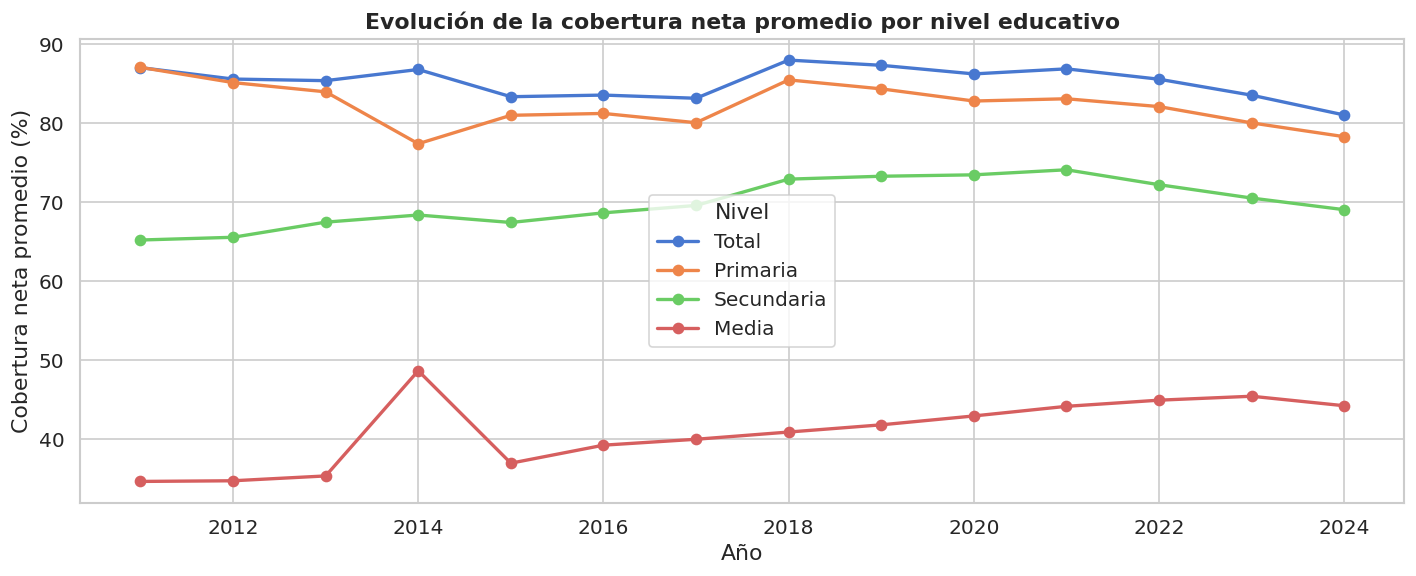

In [7]:
df_bach['a_o'] = pd.to_numeric(df_bach['a_o'], errors='coerce')

evol = (
    df_bach
    .groupby('a_o')[['cobertura_neta', 'cobertura_neta_primaria',
                      'cobertura_neta_secundaria', 'cobertura_neta_media']]
    .mean()
    .dropna(how='all')
)

fig, ax = plt.subplots(figsize=(12, 5))
for col, label in zip(evol.columns, ['Total', 'Primaria', 'Secundaria', 'Media']):
    ax.plot(evol.index, evol[col], marker='o', lw=2, label=label)

ax.set_title('Evolución de la cobertura neta promedio por nivel educativo', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Cobertura neta promedio (%)')
ax.legend(title='Nivel')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

---
## Elemento 6 — Top 10 departamentos con mayor número de accesos a internet

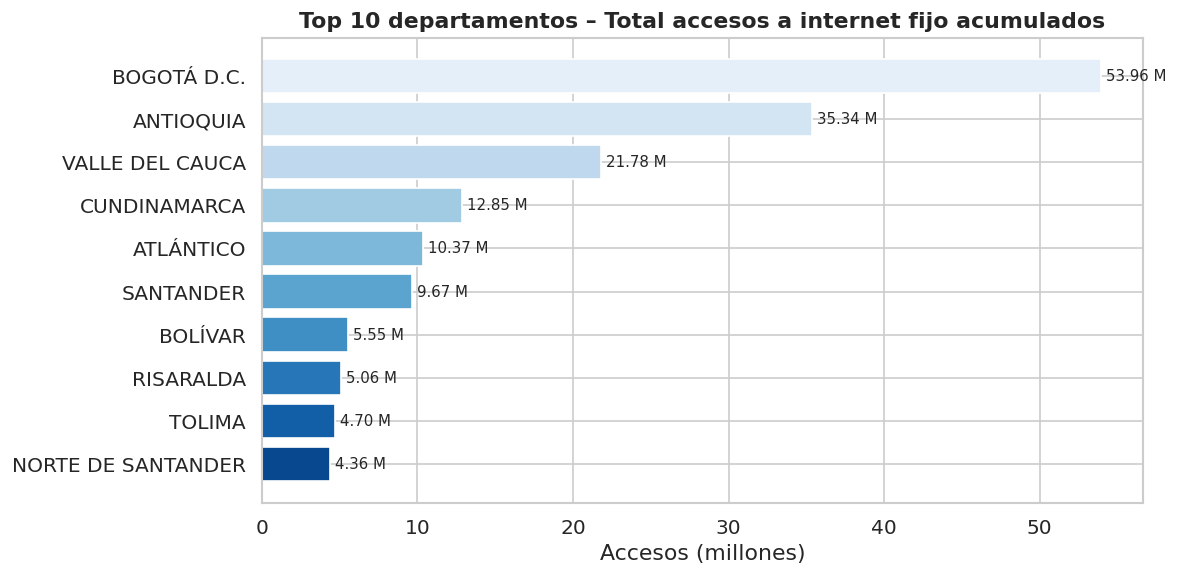


Tabla: total de accesos por departamento (top 10)


,departamento,total_accesos
0,BOGOTÁ D.C.,"53,957,365"
1,ANTIOQUIA,"35,342,014"
2,VALLE DEL CAUCA,"21,783,112"
3,CUNDINAMARCA,"12,850,353"
4,ATLÁNTICO,"10,366,668"
5,SANTANDER,"9,668,325"
6,BOLÍVAR,"5,551,870"
7,RISARALDA,"5,059,700"
8,TOLIMA,"4,697,547"
9,NORTE DE SANTANDER,"4,364,663"


In [8]:
top_dpto = (
    df_internet
    .groupby('departamento')['no_de_accesos']
    .sum()
    .nlargest(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_dpto.index, top_dpto.values / 1e6,
               color=sns.color_palette('Blues_r', 10), edgecolor='white')
ax.bar_label(bars, fmt='%.2f M', padding=3, fontsize=9)
ax.set_title('Top 10 departamentos – Total accesos a internet fijo acumulados', fontweight='bold')
ax.set_xlabel('Accesos (millones)')
plt.tight_layout()
plt.show()

print('\nTabla: total de accesos por departamento (top 10)')
display(
    top_dpto.sort_values(ascending=False)
    .rename('total_accesos')
    .reset_index()
    .assign(total_accesos=lambda d: d['total_accesos'].map('{:,.0f}'.format))
)

---
## Elemento 7 — Participación de tecnologías de acceso a internet

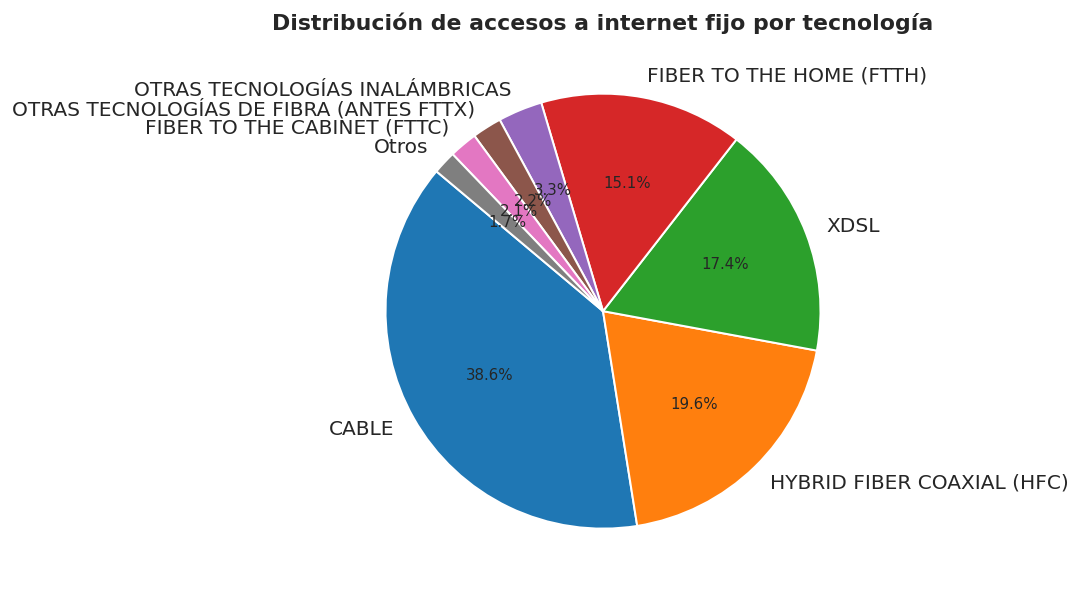

In [9]:
tech = (
    df_internet
    .groupby('tecnologia')['no_de_accesos']
    .sum()
    .sort_values(ascending=False)
)

umbral = tech.sum() * 0.02
tech_plot = tech[tech >= umbral].copy()
otros = tech[tech < umbral].sum()
if otros > 0:
    tech_plot['Otros'] = otros

fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(
    tech_plot.values,
    labels=tech_plot.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('tab10', len(tech_plot)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('Distribución de accesos a internet fijo por tecnología', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Elemento 8 — Correlación entre indicadores de cobertura y deserción

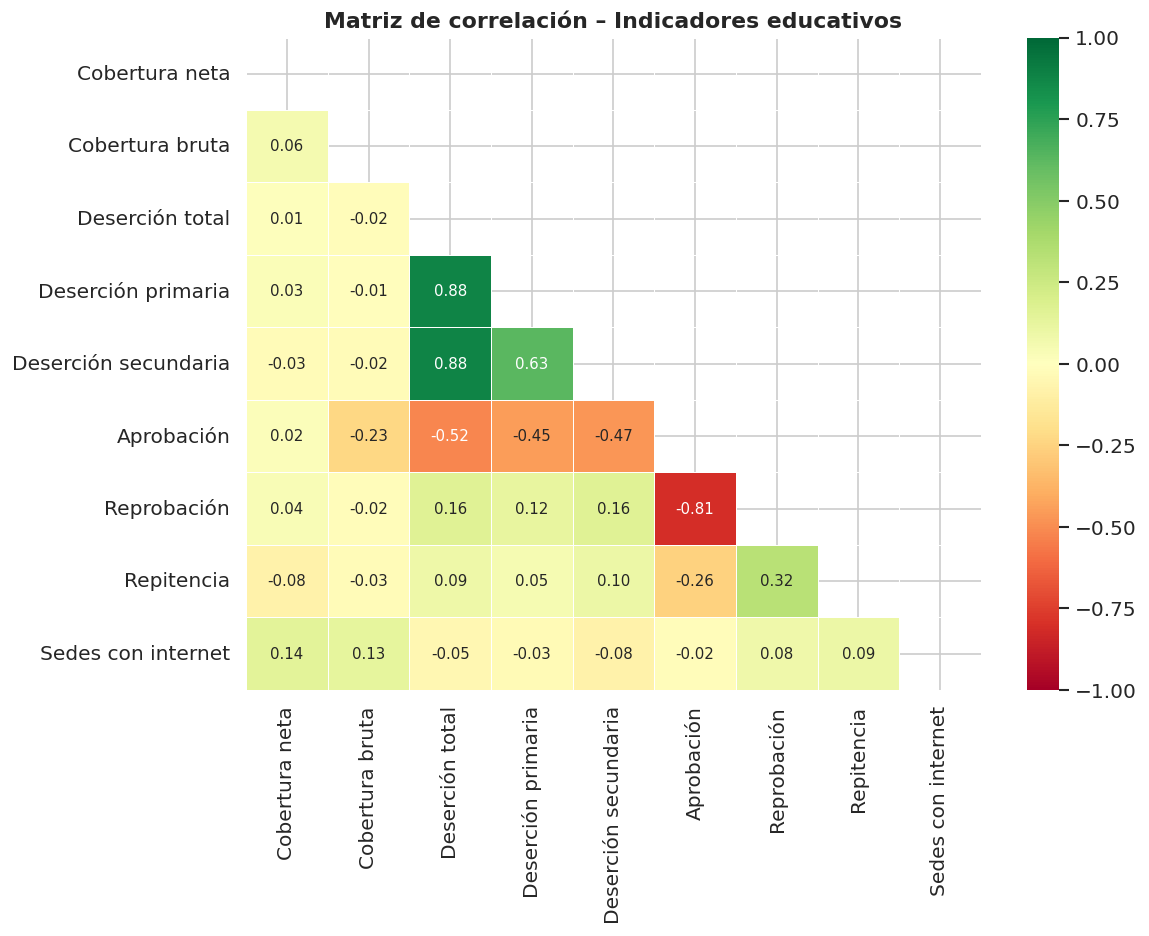

In [10]:
cols_corr = [
    'cobertura_neta', 'cobertura_bruta',
    'deserci_n', 'deserci_n_primaria', 'deserci_n_secundaria',
    'aprobaci_n', 'reprobaci_n', 'repitencia',
    'sedes_conectadas_a_internet'
]
labels_corr = [
    'Cobertura neta', 'Cobertura bruta',
    'Deserción total', 'Deserción primaria', 'Deserción secundaria',
    'Aprobación', 'Reprobación', 'Repitencia',
    'Sedes con internet'
]

corr_mat = df_bach[cols_corr].corr()
corr_mat.index   = labels_corr
corr_mat.columns = labels_corr

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Matriz de correlación – Indicadores educativos', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Elemento 9 — Boxplot: puntaje en Inglés según tipo de colegio (oficial vs no oficial)

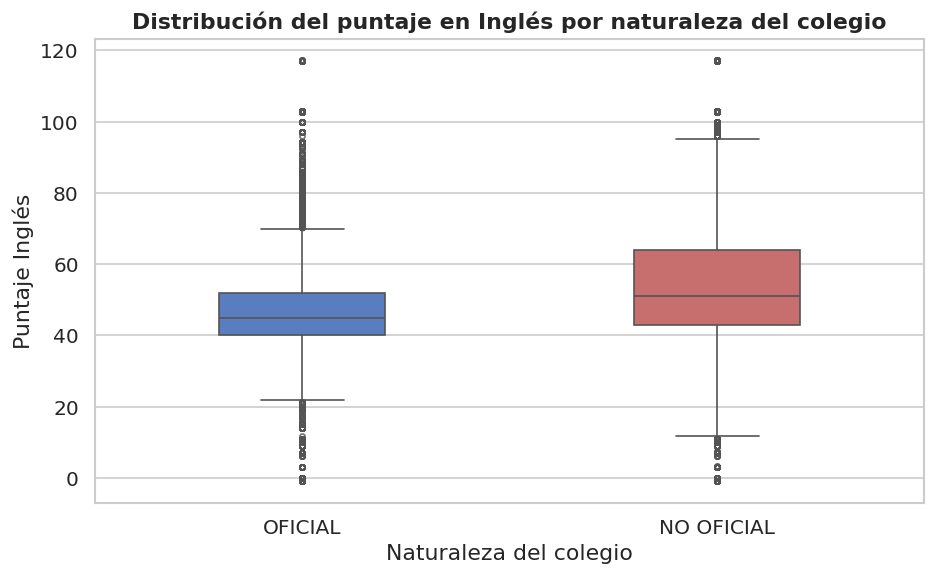


Estadísticos descriptivos por naturaleza del colegio:


,count,mean,std,min,25%,50%,75%,max
cole_naturaleza,,,,,,,,
NO OFICIAL,1974643.0,54.03,15.56,-1.0,43.0,51.0,64.0,117.29
OFICIAL,5130852.0,46.50,9.90,-1.0,40.0,45.0,52.0,117.29


In [11]:
icfes_nat = df_icfes[
    df_icfes['cole_naturaleza'].isin(['OFICIAL', 'NO OFICIAL']) &
    df_icfes['punt_ingles'].notna()
].copy()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=icfes_nat, x='cole_naturaleza', y='punt_ingles',
    palette=['#4878CF', '#D65F5F'], width=0.4,
    flierprops={'marker': '.', 'alpha': 0.3}, ax=ax
)
ax.set_title('Distribución del puntaje en Inglés por naturaleza del colegio', fontweight='bold')
ax.set_xlabel('Naturaleza del colegio')
ax.set_ylabel('Puntaje Inglés')
plt.tight_layout()
plt.show()

print('\nEstadísticos descriptivos por naturaleza del colegio:')
display(icfes_nat.groupby('cole_naturaleza')['punt_ingles'].describe().round(2))

---
## Elemento 10 — Internet en el hogar vs puntaje en Matemáticas

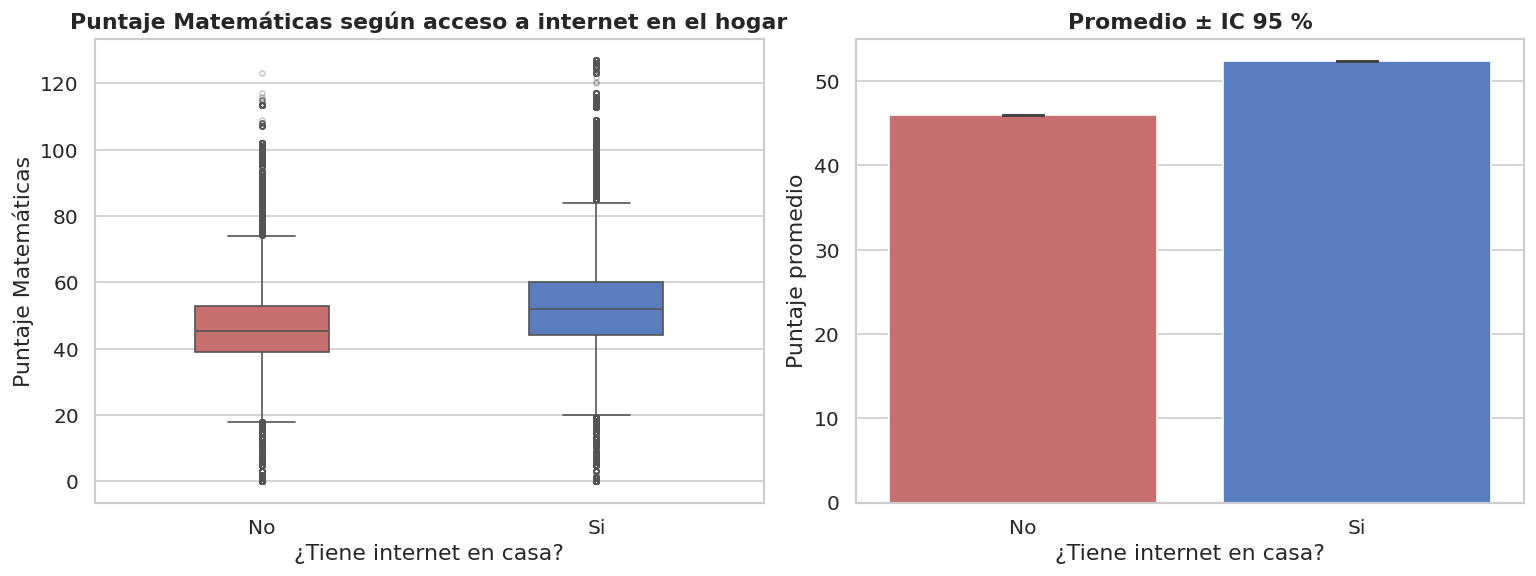


Estadísticos descriptivos por disponibilidad de internet en el hogar:


,count,mean,std,min,25%,50%,75%,max
fami_tieneinternet,,,,,,,,
No,3184398.0,45.94,10.54,0.0,39.0,45.38,53.0,123.0
Si,3733675.0,52.35,12.17,0.0,44.0,52.00,60.0,127.0


In [12]:
icfes_inet = df_icfes[
    df_icfes['fami_tieneinternet'].isin(['Si', 'No']) &
    df_icfes['punt_matematicas'].notna()
].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=icfes_inet, x='fami_tieneinternet', y='punt_matematicas',
    palette=['#D65F5F', '#4878CF'], width=0.4,
    flierprops={'marker': '.', 'alpha': 0.3}, ax=axes[0]
)
axes[0].set_title('Puntaje Matemáticas según acceso a internet en el hogar', fontweight='bold')
axes[0].set_xlabel('¿Tiene internet en casa?')
axes[0].set_ylabel('Puntaje Matemáticas')

sns.barplot(
    data=icfes_inet, x='fami_tieneinternet', y='punt_matematicas',
    palette=['#D65F5F', '#4878CF'], capsize=0.12, errwidth=1.8, ax=axes[1]
)
axes[1].set_title('Promedio ± IC 95 %', fontweight='bold')
axes[1].set_xlabel('¿Tiene internet en casa?')
axes[1].set_ylabel('Puntaje promedio')

plt.tight_layout()
plt.show()

print('\nEstadísticos descriptivos por disponibilidad de internet en el hogar:')
display(icfes_inet.groupby('fami_tieneinternet')['punt_matematicas'].describe().round(2))

---
## Elemento 11 — Accesos a internet por segmento de usuario (residencial vs corporativo)

Tabla: accesos a internet por segmento de usuario


ValueError: unmatched '{' in format spec

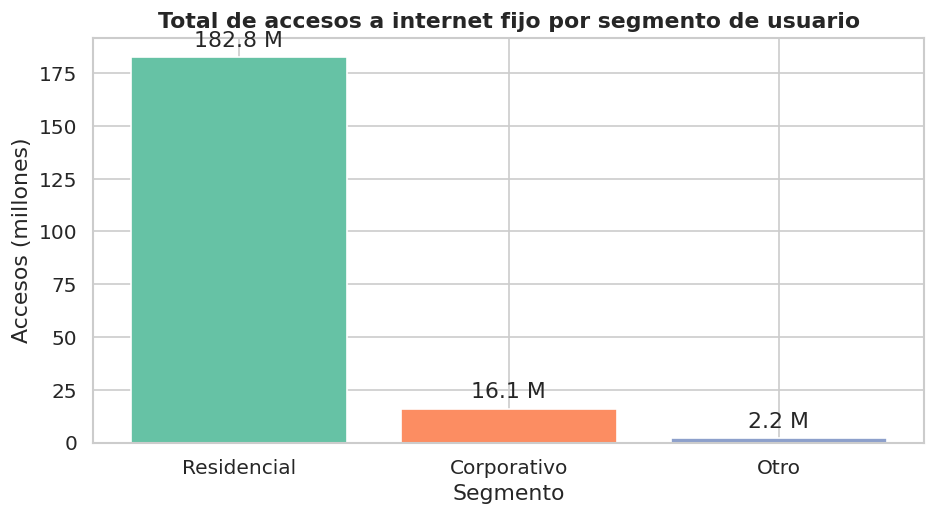

In [13]:
def clasificar_segmento(seg):
    if pd.isna(seg):
        return 'Sin clasificar'
    seg_l = str(seg).lower()
    if 'residencial' in seg_l or 'estrato' in seg_l:
        return 'Residencial'
    if 'corporativo' in seg_l or 'empresa' in seg_l:
        return 'Corporativo'
    return 'Otro'

df_internet['segmento_cat'] = df_internet['segmento'].apply(clasificar_segmento)

seg_agg = (
    df_internet
    .groupby('segmento_cat')['no_de_accesos']
    .agg(['sum', 'mean', 'count'])
    .rename(columns={'sum': 'Total accesos', 'mean': 'Promedio', 'count': 'Registros'})
    .sort_values('Total accesos', ascending=False)
)

print('Tabla: accesos a internet por segmento de usuario')
display(seg_agg.style.format({'Total accesos': '{:,.0f}', 'Promedio': '{:,.1f}', 'Registros': '{:,'}))

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(
    seg_agg.index, seg_agg['Total accesos'] / 1e6,
    color=sns.color_palette('Set2', len(seg_agg)), edgecolor='white'
)
ax.bar_label(bars, fmt='%.1f M', padding=4)
ax.set_title('Total de accesos a internet fijo por segmento de usuario', fontweight='bold')
ax.set_ylabel('Accesos (millones)')
ax.set_xlabel('Segmento')
plt.tight_layout()
plt.show()

---
## Elemento 12 — Ranking: tasa de deserción promedio por departamento

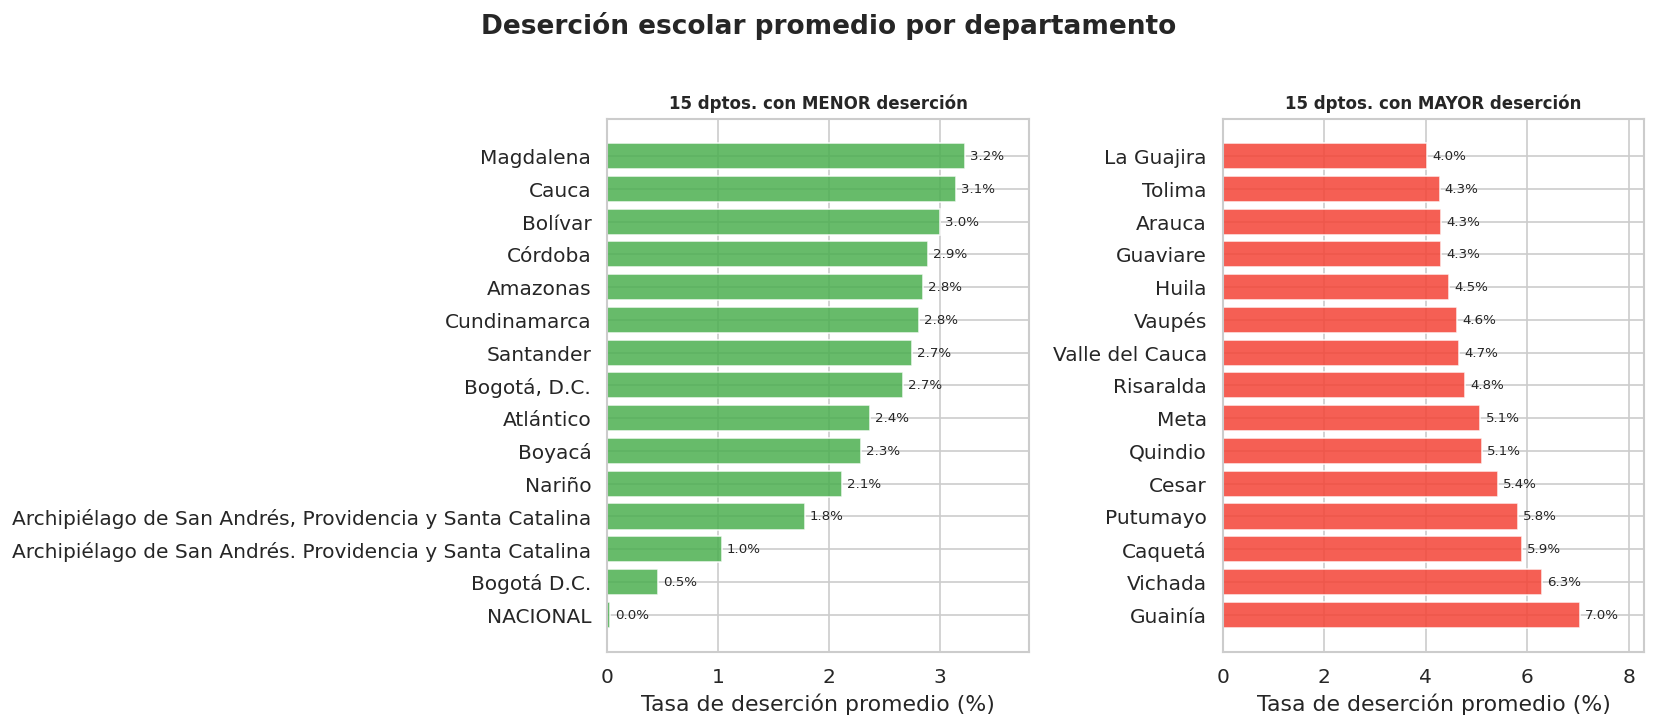

In [14]:
deser_dpto = (
    df_bach
    .groupby('departamento')['deserci_n']
    .mean()
    .dropna()
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, subset, title, color in [
    (axes[0], deser_dpto.head(15), '15 dptos. con MENOR deserción', '#4CAF50'),
    (axes[1], deser_dpto.tail(15).sort_values(ascending=False), '15 dptos. con MAYOR deserción', '#F44336')
]:
    bars = ax.barh(subset.index, subset.values, color=color, edgecolor='white', alpha=0.85)
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Tasa de deserción promedio (%)')
    ax.set_xlim(0, subset.values.max() * 1.18)

fig.suptitle('Deserción escolar promedio por departamento', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Resumen ejecutivo

| # | Elemento | Dataset |
|---|---|---|
| 1 | Estadísticos descriptivos generales | Los tres |
| 2 | Tabla de valores nulos | Los tres |
| 3 | Histogramas de puntajes Inglés y Matemáticas | ICFES |
| 4 | Puntaje promedio por estrato y género (gráfica + tabla) | ICFES |
| 5 | Evolución temporal de cobertura neta por nivel | Bachillerato |
| 6 | Top 10 departamentos en accesos a internet (gráfica + tabla) | Internet |
| 7 | Participación de tecnologías de acceso (torta) | Internet |
| 8 | Matriz de correlación entre indicadores educativos | Bachillerato |
| 9 | Boxplot: puntaje Inglés por naturaleza del colegio | ICFES |
| 10 | Internet en el hogar vs puntaje Matemáticas (boxplot + barras) | ICFES |
| 11 | Accesos por segmento de usuario (tabla + barras) | Internet |
| 12 | Ranking deserción por departamento (mejor/peor 15) | Bachillerato |